We need to evaluate how the deicison analysis, the basic and advanced implementations, performed.

In [8]:
#Imports
import argparse
import json
import os
import pickle
import sys
import warnings
from pathlib import Path

import pm4py
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.stats import chi2_contingency, ks_2samp
from scipy.spatial.distance import jensenshannon

In [9]:
%matplotlib inline
warnings.filterwarnings("ignore")

In [10]:
#Colors symbolizing..
c_real = "#0A917A"
c_basic = "#3498db"
c_advanced = "#e74c3c"
c_neutral = "#95a5a6"


In [11]:
#path names
real_log_path = "data/BPI Challenge 2017.xes.gz"
rules_path = "decision_analysis/decision_prob_rules.json"
model_path = "decision_analysis/simulation_brain.pkl"
sim_basic_path = "sim_output/sim_basic.csv"
sim_adv_path = "sim_output/sim_advanced.csv"
output_dir = Path("evaluation_results")
output_dir.mkdir(parents=True, exist_ok=True)


In [12]:
#Loading real event log
real_df = pm4py.convert_to_dataframe(pm4py.read_xes("/Users/zeynepcetin/bppso-groupwork-1/data/BPI Challenge 2017.xes.gz"))
real_df["time:timestamp"] = pd.to_datetime(real_df["time:timestamp"], utc=True)
if "lifecycle:transition" in real_df.columns:
        real_df = real_df[real_df["lifecycle:transition"].str.lower() == "complete"].copy()

real_df = real_df.sort_values(["case:concept:name", "time:timestamp"])
print(f"    -> {len(real_df):,} completed events, {real_df['case:concept:name'].nunique():,} cases.")

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:17<00:00, 1817.35it/s]


    -> 475,306 completed events, 31,509 cases.


I want to compare how my basic and advanced router differ from the event log. Thus, I decided to compare the data distributions between basic vs real, advanced vs real. For this evaluation I decided to use Jensen-Shannon Divergence because it is a good metric for goodness of fit. The main goal with JS Divergence is to find out the similarity between two probability distributions. 

In [13]:
#Loading the simulation data
sim_df = pd.read_csv("/Users/zeynepcetin/bppso-groupwork-1/sim_output/final_simulation_log.csv")
sim_df["time:timestamp"] = pd.to_datetime(sim_df["time:timestamp"], utc=True, errors="coerce")
if "lifecycle:transition" in sim_df.columns:
    sim_df = sim_df[sim_df["lifecycle:transition"].str.lower() == "complete"].copy()
sim_df = sim_df.sort_values(["case:concept:name", "time:timestamp"])
print(f"     {len(sim_df):,} events, {sim_df['case:concept:name'].nunique():,} cases.")


     1,796 events, 100 cases.


In [15]:
df_real = real_df
with open("/Users/zeynepcetin/bppso-groupwork-1/decision_analysis/decision_prob_rules.json") as f:
    basic_rules = json.load(f)

df_basic = pd.read_csv(sim_basic_path) if os.path.exists(sim_basic_path) else None
df_adv = pd.read_csv(sim_adv_path) if os.path.exists(sim_adv_path) else None

In [16]:
def jsd_metric(p, q):
    keys = sorted(set(p) | set(q))
    pv = np.array([p.get(k, 0.0) for k in keys], dtype=float)
    qv = np.array([q.get(k, 0.0) for k in keys], dtype=float)
    if pv.sum() > 0: pv /= pv.sum()
    if qv.sum() > 0: qv /= qv.sum()
    return float(jensenshannon(pv, qv))

def get_activity_freq(df):
    counts = df["concept:name"].value_counts()
    return (counts / counts.sum()).to_dict()

def get_empirical_transitions(df):
    df = df.copy()
    df["_next"] = df.groupby("case:concept:name")["concept:name"].shift(-1)
    branching = df.dropna(subset=["_next"])
    branching = branching[branching["concept:name"] != branching["_next"]]
    result = {}
    for act, grp in branching.groupby("concept:name"):
        counts = grp["_next"].value_counts()
        result[act] = (counts / counts.sum()).to_dict()
    return result

real_trans = get_empirical_transitions(real_df)

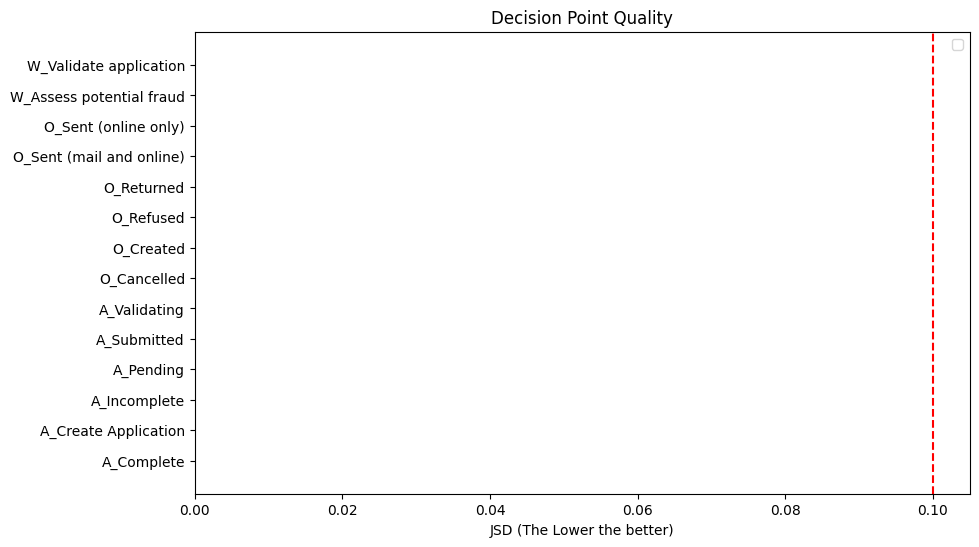

In [19]:
# JSD
rows = []
for act, real_dist in sorted(real_trans.items()):
    if len([v for v in real_dist.values() if v > 0.01]) > 1: # only decision branches
        b_dist = basic_rules.get(act, {})
        b_jsd = jsd_metric(real_dist, b_dist) if b_dist else 1.0
        
        rows.append({
            "Activity": act,
            "Basic_JSD": round(b_jsd, 4)
        })

df_l1 = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
plt.barh(df_l1["Activity"], df_l1["Basic_JSD"], color= c_basic)
plt.axvline(0.1, color="red", linestyle="--", label="")
plt.xlabel("JSD (The Lower the better)")
plt.title("Decision Point Quality")
plt.legend()
plt.show()

In [18]:
def compare_systems(df_real, df_sim, label, color):
    if df_sim is None: return
    
    real_af = get_activity_freq(df_real)
    sim_af = get_activity_freq(df_sim)
    
    score = jsd_metric(real_af, sim_af)
    print(f"{label} Activity Frequency JSD: {score:.4f}")

    real_cl = df_real.groupby("case:concept:name")["concept:name"].count()
    sim_cl = df_sim.groupby("case:concept:name")["concept:name"].count()
    
    plt.hist(real_cl, bins=30, alpha=0.5, label="Gerçek", color= c_real, density=True)
    plt.hist(sim_cl, bins=30, alpha=0.5, label=label, color=color, density=True)
    plt.title(f"{label} vs Reality: Case Length Distribution")
    plt.legend()
    plt.show()

compare_systems(real_df, df_basic, "BasicRouter", c_basic)

Advanced Part

In [ ]:
def load_advanced_model(path):
    with open(path, "rb") as f:
        pkg = pickle.load(f)
    return pkg["model"], pkg["bins"]
model, bins = load_advanced_model(model_path)